In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/deep-past-initiative-machine-translation/sample_submission.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/bibliography.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/publications.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/Sentences_Oare_FirstWord_LinNum.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/OA_Lexicon_eBL.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/eBL_Dictionary.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/train.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/test.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/published_texts.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/resources.csv
/kaggle/input/datasets/jiayuanshe/package/portalocker-3.2.0-py3-none-any.whl
/kaggle/input/datasets/jiayuanshe/package/sacrebleu-2.6.0-py

In [2]:
import matplotlib.pyplot as plt
import os, sys, json, math, random
import numpy as np
import pandas as pd
import torch

print("python:", sys.version)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("gpu count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.8.0+cu126
cuda available: True
gpu: Tesla T4
gpu count: 2
0 Tesla T4
1 Tesla T4


In [3]:
INPUT_DIR = "/kaggle/input/competitions/deep-past-initiative-machine-translation"

for root, _, files in os.walk(INPUT_DIR):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/competitions/deep-past-initiative-machine-translation/sample_submission.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/bibliography.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/publications.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/Sentences_Oare_FirstWord_LinNum.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/OA_Lexicon_eBL.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/eBL_Dictionary.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/train.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/test.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/published_texts.csv
/kaggle/input/competitions/deep-past-initiative-machine-translation/resources.csv


In [4]:
train_path = f"{INPUT_DIR}/train.csv"
test_path  = f"{INPUT_DIR}/test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("train shape:", train_df.shape)
print("test  shape:", test_df.shape)

print("\ntrain columns:", list(train_df.columns))
print("test  columns:", list(test_df.columns))

train_df.head()

train shape: (1561, 3)
test  shape: (4, 5)

train columns: ['oare_id', 'transliteration', 'translation']
test  columns: ['id', 'text_id', 'line_start', 'line_end', 'transliteration']


,oare_id,transliteration,translation
0,004a7dbd-57ce-46f8-9691-409be61c676e,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ..."
1,0064939c-59b9-4448-a63d-34612af0a1b5,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...
2,0073f2c0-524c-4bbf-915a-8c1772a4fb98,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,<gap> he did not give you a textile. He return...
3,009fb838-8038-42bc-ad34-5f795b3840ee,KIŠIB šu-{d}EN.LÍL DUMU šu-ku-bi-im KIŠIB ṣí-l...,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilū..."
4,00aa1c55-c80c-4346-a159-73ad43ab0ff7,um-ma šu-ku-tum-ma a-na IŠTAR-lá-ma-sí ù ni-ta...,From Šukkutum to Ištar-lamassī and Nitahšušar:...


In [5]:
SRC_COL_CANDIDATES = ["transliteration", "source", "src", "akkadian"]
TGT_COL_CANDIDATES = ["translation", "target", "tgt", "english"]

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

SRC_COL = pick_col(train_df, SRC_COL_CANDIDATES)
TGT_COL = pick_col(train_df, TGT_COL_CANDIDATES)

assert SRC_COL is not None, f"Can't find source column in train.csv, tried {SRC_COL_CANDIDATES}"
assert TGT_COL is not None, f"Can't find target column in train.csv, tried {TGT_COL_CANDIDATES}"

print("Using SRC_COL =", SRC_COL)
print("Using TGT_COL =", TGT_COL)

Using SRC_COL = transliteration
Using TGT_COL = translation


In [6]:
import re

def normalize_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace("\u200b", " ").strip()  # 零宽字符
    s = re.sub(r"\s+", " ", s)
    return s

train_df[SRC_COL] = train_df[SRC_COL].map(normalize_text)
train_df[TGT_COL] = train_df[TGT_COL].map(normalize_text)
test_df["transliteration"] = test_df["transliteration"].map(normalize_text) if "transliteration" in test_df.columns else test_df.iloc[:, 1].map(normalize_text)

train_df[[SRC_COL, TGT_COL]].head()

,transliteration,translation
0,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ..."
1,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...
2,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,<gap> he did not give you a textile. He return...
3,KIŠIB šu-{d}EN.LÍL DUMU šu-ku-bi-im KIŠIB ṣí-l...,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilū..."
4,um-ma šu-ku-tum-ma a-na IŠTAR-lá-ma-sí ù ni-ta...,From Šukkutum to Ištar-lamassī and Nitahšušar:...


In [7]:
from sklearn.model_selection import train_test_split

DOC_COL_CANDIDATES = ["doc_id", "document_id", "text_id", "tablet_id"]
DOC_COL = next((c for c in DOC_COL_CANDIDATES if c in train_df.columns), None)
#print("DOC_COL:", DOC_COL)

VAL_RATIO = 0.05
SEED = 42

if DOC_COL is None:
    tr_df, va_df = train_test_split(train_df, test_size=VAL_RATIO, random_state=SEED)
else:
    docs = train_df[DOC_COL].dropna().unique()
    tr_docs, va_docs = train_test_split(docs, test_size=VAL_RATIO, random_state=SEED)
    tr_df = train_df[train_df[DOC_COL].isin(tr_docs)].copy()
    va_df = train_df[train_df[DOC_COL].isin(va_docs)].copy()

print("train split:", tr_df.shape, "valid split:", va_df.shape)

train split: (1482, 3) valid split: (79, 3)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "/kaggle/input/models/jiayuanshe/byt5-small/transformers/default/1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Loaded:", MODEL_NAME)

2026-03-02 21:28:14.314128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772486894.551772      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772486894.618330      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772486895.142068      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772486895.142115      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772486895.142118      24 computation_placer.cc:177] computation placer alr

Loaded: /kaggle/input/models/jiayuanshe/byt5-small/transformers/default/1


In [ ]:
from datasets import Dataset

TASK_PREFIX = "You are a Akkadian expert. Translate Akkadian latin-transliteration to English: "

def to_dataset(df):
    return Dataset.from_dict({
        "src": (TASK_PREFIX + df[SRC_COL]).tolist(),
        "tgt": df[TGT_COL].tolist()
    })

train_ds = to_dataset(tr_df)
valid_ds = to_dataset(va_df)

MAX_SRC_LEN = 512
MAX_TGT_LEN = 256

def preprocess(batch):
    model_inputs = tokenizer(
        batch["src"],
        max_length=MAX_SRC_LEN,
        truncation=True
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            batch["tgt"],
            max_length=MAX_TGT_LEN,
            truncation=True
        )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
valid_tok = valid_ds.map(preprocess, batched=True, remove_columns=valid_ds.column_names)

#train_tok[0]


Map:   0%|          | 0/1482 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/79 [00:00<?, ? examples/s]

In [ ]:
print("===== RAW DATA =====")
print("train_df:", len(tr_df))
print("valid_df:", len(va_df))
print("test_df :", len(test_df))

print("\n===== TOKENIZED DATA =====")
print("train_tok:", len(train_tok))
print("valid_tok:", len(valid_tok))

def count_empty(df, col):
    return (df[col].astype(str).str.strip() == "").sum()

print("\n===== EMPTY TEXT CHECK =====")
print("empty train src:", count_empty(train_df, SRC_COL))
print("empty train tgt:", count_empty(train_df, TGT_COL))


===== RAW DATA =====
train_df: 1482
valid_df: 79
test_df : 4

===== TOKENIZED DATA =====
train_tok: 1482
valid_tok: 79

===== EMPTY TEXT CHECK =====
empty train src: 0
empty train tgt: 0


In [11]:
train_src_len = train_df[SRC_COL].astype(str).apply(len)
train_tgt_len = train_df[TGT_COL].astype(str).apply(len)

print("Source length: mean =", train_src_len.mean(), "max =", train_src_len.max())
print("Target length: mean =", train_tgt_len.mean(), "max =", train_tgt_len.max())


Source length: mean = 428.8199871877002 max = 966
Target length: mean = 500.3273542600897 max = 3995


In [12]:
! pip install /kaggle/input/datasets/jiayuanshe/package/evaluate-0.4.6-py3-none-any.whl
! pip install /kaggle/input/datasets/jiayuanshe/package/portalocker-3.2.0-py3-none-any.whl
! pip install /kaggle/input/datasets/jiayuanshe/package/sacrebleu-2.6.0-py3-none-any.whl


Processing /kaggle/input/datasets/jiayuanshe/package/evaluate-0.4.6-py3-none-any.whl
Processing /kaggle/input/datasets/jiayuanshe/package/portalocker-3.2.0-py3-none-any.whl
Processing /kaggle/input/datasets/jiayuanshe/package/sacrebleu-2.6.0-py3-none-any.whl


In [ ]:
import sacrebleu
import math
import numpy as np

bleu_metric = sacrebleu.BLEU()
chrfpp_metric = sacrebleu.CHRF(word_order=2)   # chrF++

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    pred_str = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    label_str = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # sacrebleu expects list[str] + list[list[str]]
    bleu = bleu_metric.corpus_score(pred_str, [label_str]).score
    chrfpp = chrfpp_metric.corpus_score(pred_str, [label_str]).score

    combo = math.sqrt(max(bleu, 0.0) * max(chrfpp, 0.0))

    return {
        "bleu": bleu,
        "chrfpp": chrfpp,
        "dpi_score": combo
    }


In [14]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

OUT_DIR = "byt5_akkadian_en"

args = Seq2SeqTrainingArguments(
    output_dir=OUT_DIR,

    # NEW API names
    eval_strategy="steps",
    save_strategy="steps",
    logging_strategy="steps",

    eval_steps=500,
    save_steps=500,
    logging_steps=50,
    save_total_limit=2,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,

    learning_rate=2e-4,
    num_train_epochs=6,
    warmup_ratio=0.05,
    weight_decay=0.01,

    predict_with_generate=True,
    generation_max_length=MAX_TGT_LEN,

    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=valid_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)


/tmp/ipykernel_24/3922205219.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [15]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss


TrainOutput(global_step=144, training_loss=1.3585674497816298, metrics={'train_runtime': 1920.2074, 'train_samples_per_second': 4.631, 'train_steps_per_second': 0.075, 'total_flos': 8083862197991424.0, 'train_loss': 1.3585674497816298, 'epoch': 6.0})

train loss points: 2
eval loss points : 0


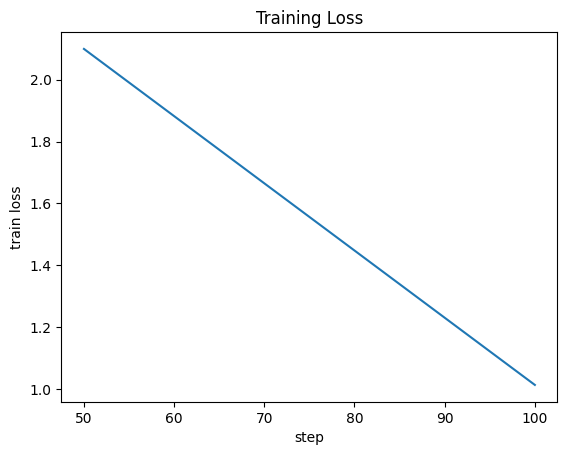

,loss,grad_norm,learning_rate,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.0989,1.603473,0.000140,2.086253,50,NaN,NaN,NaN,NaN,NaN
1,1.0143,0.437986,0.000066,4.172507,100,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,6.000000,144,1920.2074,4.631,0.075,8.083862e+15,1.358567


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

train_loss = df_logs[df_logs["loss"].notna()][["step", "loss"]].copy() if "loss" in df_logs.columns else pd.DataFrame()
eval_loss  = df_logs[df_logs["eval_loss"].notna()][["step", "eval_loss"]].copy() if "eval_loss" in df_logs.columns else pd.DataFrame()

print("train loss points:", len(train_loss))
print("eval loss points :", len(eval_loss))

# plot train loss
if len(train_loss) > 0:
    plt.figure()
    plt.plot(train_loss["step"], train_loss["loss"])
    plt.xlabel("step")
    plt.ylabel("train loss")
    plt.title("Training Loss")
    plt.show()

# plot validation loss
if len(eval_loss) > 0:
    plt.figure()
    plt.plot(eval_loss["step"], eval_loss["eval_loss"])
    plt.xlabel("step")
    plt.ylabel("eval loss")
    plt.title("Validation Loss")
    plt.show()

df_logs.tail(10)


In [17]:
metrics = trainer.evaluate()
metrics

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.7099460363388062,
 'eval_bleu': 7.035952266564587,
 'eval_chrfpp': 22.903118590418007,
 'eval_dpi_score': 12.694299868746173,
 'eval_runtime': 54.7996,
 'eval_samples_per_second': 1.442,
 'eval_steps_per_second': 0.365,
 'epoch': 6.0}

In [18]:
from tqdm.auto import tqdm

TEST_SRC_COL = "transliteration" if "transliteration" in test_df.columns else test_df.columns[1]

test_src = (TASK_PREFIX + test_df[TEST_SRC_COL].astype(str)).tolist()

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BATCH = 16
all_preds = []

for i in tqdm(range(0, len(test_src), BATCH)):
    batch_text = test_src[i:i+BATCH]
    enc = tokenizer(batch_text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_SRC_LEN).to(device)
    with torch.no_grad():
        gen = model.generate(
            **enc,
            max_new_tokens=MAX_TGT_LEN,
            #max_new_tokens = 512,
            num_beams=4
        )
    out = tokenizer.batch_decode(gen, skip_special_tokens=True)
    all_preds.extend(out)

print("generated:", len(all_preds))
print(all_preds[:3])


  0%|          | 0/1 [00:00<?, ?it/s]

generated: 4
['Seal of Kanesh, seal of Kanesh, seal of Aaqil, seal of Aqil, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahu', 'Seal of Muppim, Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ahum, seal of Ali-ah', 'Seal of Muppini, seal of Taameani, seal of Amurrum, seal of Amurrum, seal of Amurrum, seal of Amurrum, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, seal of Aumir, sea']


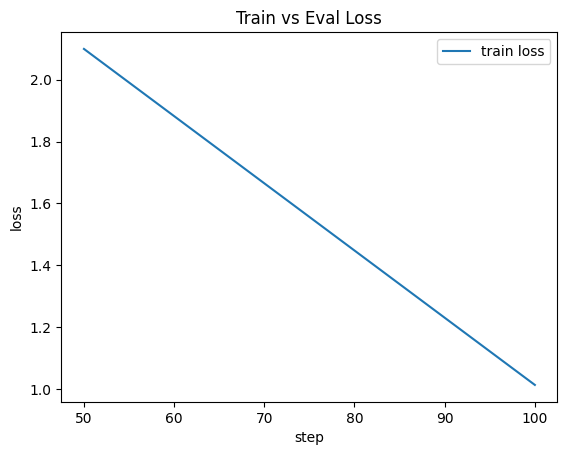

In [19]:

plt.figure()

if len(train_loss) > 0:
    plt.plot(train_loss["step"], train_loss["loss"], label="train loss")

if len(eval_loss) > 0:
    plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="eval loss")

plt.xlabel("step")
plt.ylabel("loss")
plt.title("Train vs Eval Loss")
plt.legend()
plt.show()

In [20]:
sub = pd.DataFrame({
    "id": test_df["id"].values,
    "translation": all_preds
})

sub.to_csv("submission.csv", index=False)
sub.head()


,id,translation
0,0,"Seal of Kanesh, seal of Kanesh, seal of Aaqil,..."
1,1,"Seal of Muppim, Ali-ahum, seal of Ali-ahum, se..."
2,2,"Seal of Muppini, seal of Taameani, seal of Amu..."
3,3,"To Kar, Karma and Wabarratum, son of Wabarratu..."


In [ ]:
# evaluate
import math

bleu_metric = sacrebleu.BLEU()                 # corpus BLEU
chrfpp_metric = sacrebleu.CHRF(word_order=2)   # chrF++: word_order=2 :contentReference[oaicite:2]{index=2}

def dpi_official_score(preds, refs):
    """
    Compute the official DPI score, which is the geometric mean of BLEU and chrF++.
    """

    bleu = bleu_metric.corpus_score(preds, [refs]).score
    chrfpp = chrfpp_metric.corpus_score(preds, [refs]).score
    combo = math.sqrt(max(bleu, 0.0) * max(chrfpp, 0.0))  # Score = sqrt(BLEU * chrF++) :contentReference[oaicite:3]{index=3}
    return {"bleu": bleu, "chrfpp": chrfpp, "score": combo}


In [ ]:

pred_out = trainer.predict(valid_tok, max_length=MAX_TGT_LEN)

pred_ids = pred_out.predictions
label_ids = pred_out.label_ids


if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)


label_ids = np.where(label_ids != -100, label_ids, tokenizer.pad_token_id)
ref_texts = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

scores = dpi_official_score(pred_texts, ref_texts)
scores


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'bleu': 7.035952266564587,
 'chrfpp': 22.903118590418007,
 'score': 12.694299868746173}